# LangChain: Q&A over Documents

Load a CSV product catalog, embed it into an in-memory vector store,
and answer natural-language questions about it using retrieval-augmented generation (RAG).

**Concept flow:**
```
CSV file
   │  CSVLoader
   ▼
Documents  ──  OpenAIEmbeddings  ──►  DocArrayInMemorySearch (vector store)
                                              │
                                         retriever
                                              │
                              question ──► RAG chain ──► answer
```

<div align="center">

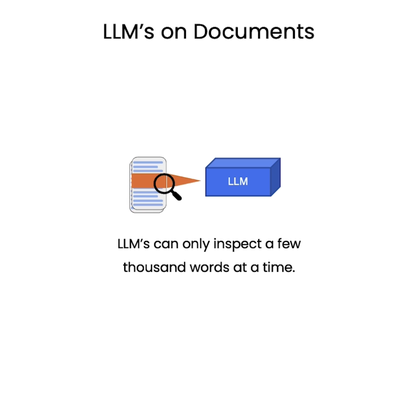

</div>

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())

llm_model = 'gpt-3.5-turbo'

In [2]:
# Install if missing:
# pip install langchain-openai langchain-community docarray

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import CSVLoader
from langchain_community.vectorstores import DocArrayInMemorySearch
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from IPython.display import display, Markdown

## Step 1 — Load documents from CSV

`CSVLoader` reads each CSV row as a separate `Document` object.
Each document's `page_content` is the row serialized as `column: value` text — this is what gets embedded and searched later.

**Problem with raw loading:** the CSV has an unnamed index column (row numbers 0, 1, 2…)
which shows up as `: 0`, `: 1` noise in the text. We fix this by reading the CSV
with pandas first to identify and drop that column before loading.

In [3]:
import pandas as pd

# Inspect the raw CSV to see column names
df = pd.read_csv('assets/OutdoorClothingCatalog_1000.csv')
print('Columns:', df.columns.tolist())
print(f'Rows   : {len(df)}')
print()
print(df.head(2))

Columns: ['Unnamed: 0', 'name', 'description']
Rows   : 1000

   Unnamed: 0                                      name  \
0           0                  Women's Campside Oxfords   
1           1  Recycled Waterhog Dog Mat, Chevron Weave   

                                         description  
0  This ultracomfortable lace-to-toe Oxford boast...  
1  Protect your floors from spills and splashing ...  


In [4]:
# The first column is an unnamed row index — drop it, save a clean CSV
df_clean = df.drop(columns=df.columns[df.columns.str.startswith('Unnamed')], errors='ignore')
clean_path = 'assets/OutdoorClothingCatalog_clean.csv'
df_clean.to_csv(clean_path, index=False)

# Load the clean CSV — each row becomes one Document
loader = CSVLoader(file_path=clean_path)
docs = loader.load()

print(f'Loaded {len(docs)} documents')
print('\nFirst document page_content:')
print(docs[0].page_content[:300])

Loaded 1000 documents

First document page_content:
name: Women's Campside Oxfords
description: This ultracomfortable lace-to-toe Oxford boasts a super-soft canvas, thick cushioning, and quality construction for a broken-in feel from the first time you put them on. 

Size & Fit: Order regular shoe size. For half sizes not offered, order up to next wh


<div align="center">

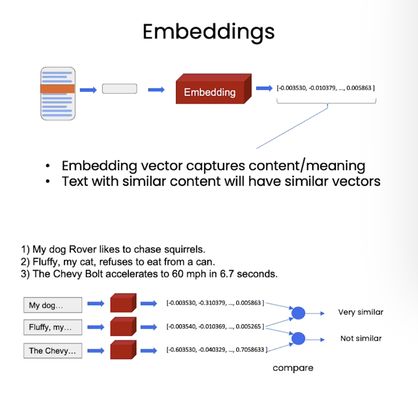

</div>

## Step 2 — Embed documents into a vector store

`OpenAIEmbeddings` converts any text into a list of 1536 numbers (a *vector*).
The key property: **similar meaning → similar numbers**.
So `'UV protection shirt'` and `'sunblock top'` will have vectors very close to each other,
even though they share no words.

`DocArrayInMemorySearch` stores all those vectors in RAM.
When you search, it computes which stored vectors are closest to your query vector
and returns those documents — this is called *semantic search*.

In [5]:
embeddings = OpenAIEmbeddings()

# Sanity check: embed one sentence and inspect the vector
sample = embeddings.embed_query('sun protection shirt')
print(f'Vector dimensions : {len(sample)}')
print(f'First 5 values    : {[round(v, 4) for v in sample[:5]]}')
print('(Each number encodes some aspect of the meaning of the text)')

Vector dimensions : 1536
First 5 values    : [-0.0155, -0.0219, 0.0108, -0.0354, -0.0036]
(Each number encodes some aspect of the meaning of the text)


In [6]:
# Embed all 1000 documents and store them — this makes one API call per batch
vectorstore = DocArrayInMemorySearch.from_documents(docs, embeddings)
print('Vector store built.')

Vector store built.


<div align="center">

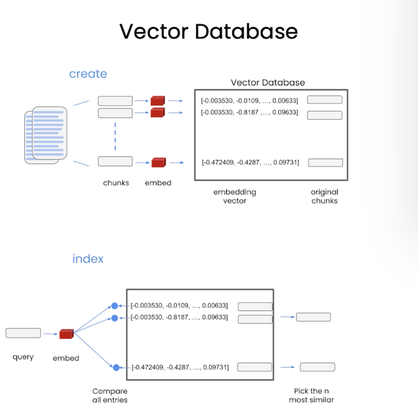

</div>

## Step 3 — Test similarity search

Before building the full RAG chain, let's verify the retriever works correctly.

A `retriever` wraps the vector store. When you call `retriever.invoke(query)` it:
1. Embeds your query into a vector
2. Finds the `k` stored documents whose vectors are most similar
3. Returns those documents

**Why k=8 for the sun protection question?**
The question asks to *list all* shirts — we need enough results to cover all variants.
For a targeted question like 'suggest one jacket' k=4 is fine.

In [7]:
retriever = vectorstore.as_retriever(search_kwargs={'k': 8})

test_query = 'shirt with sun protection'
retrieved = retriever.invoke(test_query)

print(f'Retrieved {len(retrieved)} documents for: "{test_query}"')
print()
for i, doc in enumerate(retrieved):
    # Show just the first line (product name) of each result
    first_line = doc.page_content.split('\n')[0]
    print(f'  {i+1}. {first_line}')

Retrieved 8 documents for: "shirt with sun protection"

  1. name: Sun Shield Shirt by
  2. name: Men's Plaid Tropic Shirt, Short-Sleeve
  3. name: Men's TropicVibe Shirt, Short-Sleeve
  4. name: Men's Tropical Plaid Short-Sleeve Shirt
  5. name: Women's Tropical Tee, Sleeveless
  6. name: Girls' Beachside Breeze Shirt, Half-Sleeve
  7. name: Girls' Ocean Breeze Long-Sleeve Stripe Shirt
  8. name: Sunrise Tee


<div align="center">

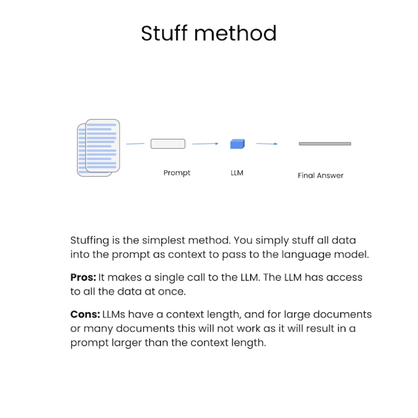

</div>

## Step 4 — Build the RAG chain

RAG = **R**etrieval-**A**ugmented **G**eneration.

The idea: instead of asking the LLM to answer from memory (which may be wrong or outdated),
we first fetch the relevant product descriptions from our catalog,
then hand them to the LLM as context and say *'answer based only on this'*.

The LCEL pipeline step by step:
```
question
   │
   ├──► retriever       # fetch 8 relevant docs from vector store
   │        │
   │    format_docs     # join doc texts into one context string
   │        │
   └──► RunnablePassthrough  # question passes through unchanged
            │
        prompt          # fills {context} and {question} into the template
            │
           llm          # generates the answer
            │
       StrOutputParser  # extracts plain string from AIMessage
            │
          answer
```

<div align="center">

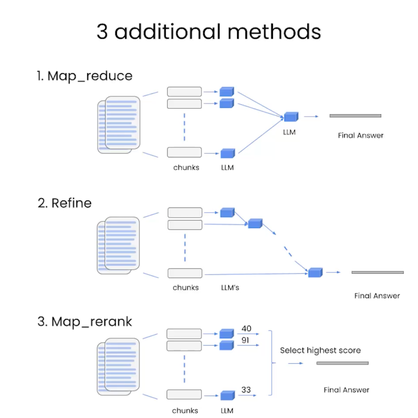

</div>

<div align="center">

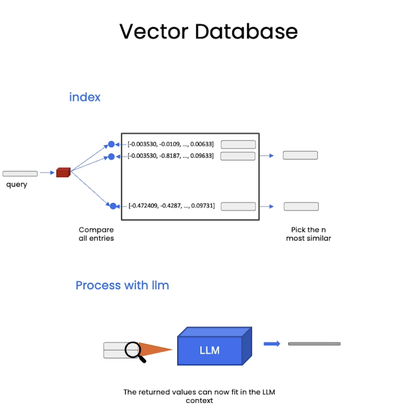

</div>

In [8]:
llm = ChatOpenAI(temperature=0.0, model=llm_model)

prompt = ChatPromptTemplate.from_template(
    'You are a helpful shopping assistant for an outdoor clothing store.\n'
    'Answer the question based ONLY on the product descriptions below.\n'
    'If the answer is not in the context, say "I don\'t have that information."\n\n'
    'PRODUCT CATALOG:\n{context}\n\n'
    'QUESTION: {question}'
)

def format_docs(documents):
    """Join retrieved document texts into one context string for the prompt."""
    return '\n\n---\n\n'.join(doc.page_content for doc in documents)

rag_chain = (
    {'context': retriever | format_docs, 'question': RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

## Step 5 — Ask questions

The chain retrieves relevant products from the catalog and answers based on them.
It cannot hallucinate products that aren't in the CSV.

In [9]:
question = (
    'Please list all your shirts with sun protection '
    'in a table in markdown and summarize each one.'
)

response = rag_chain.invoke(question)
display(Markdown(response))

| Shirt Name                        | Summary                                                                                                                                                                                                                   |
|-----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Men's Tropical Plaid Short-Sleeve | Rated UPF 50+ for superior sun protection, made of 100% polyester, wrinkle-resistant, with front and back venting and two front pockets. Imported.                                                                            |
| Men's Plaid Tropic Shirt           | Rated UPF 50+, designed for fishing, made of 52% polyester and 48% nylon, wrinkle-free, machine washable, with front and back venting and two front pockets. Imported.                                                    |
| Sun Shield Shirt                  | Made of 78% nylon and 22% Lycra Xtra Life fiber, UPF 50+ rated, wicks moisture, fits comfortably over swimsuit, abrasion-resistant, handwash, line dry. Imported.                                                         |
| Men's TropicVibe Shirt             | Built-in UPF 50+, lightweight, made of 71% nylon and 29% polyester, wrinkle-resistant, machine washable, with front and back venting and two front pockets. Imported.                                                  |
| Girls' Ocean Breeze Long-Sleeve    | Full-coverage rash guard with UPF 50+, made of Nylon Lycra®-elastane blend, quick-drying, fade-resistant, machine washable, recommended by The Skin Cancer Foundation. Imported.                                       |
| Girls' Beachside Breeze Shirt      | Swim shirt with built-in UPF 50+, made of 80% nylon and 20% Lycra Xtra Life, snag- and fade-resistant, seawater-resistant, cover-stitched seams, machine washable. Imported.                                                |
| Women's Tropical Tee              | Sleeveless button-up shirt with SunSmart™ UPF 50+, made of 71% nylon and 29% polyester, wrinkle-resistant, low-profile pockets, front and back venting, two front pockets, tool tabs, eyewear loop. Imported. |
| Sunrise Tee                       | Button-down shirt with UPF 50+, lightweight, moisture-wicking, wrinkle-free, made of 71% nylon and 29% polyester, low-profile pockets, front and back venting, two front pockets, tool tabs, eyewear loop. Imported. |

In [10]:
response = rag_chain.invoke('Do you have any waterproof jackets?')
display(Markdown(response))

Yes, we have several waterproof jackets available.

In [11]:
response = rag_chain.invoke('What is the most affordable option for hiking?')
display(Markdown(response))

The most affordable option for hiking would be the Mountain Trekkers, Suede Mesh.

```
⏺ invoke("shirts with sun protection")
          │
          ├─── retriever ──────────────────────────────────────────────┐
          │    1. embed query → [0.028, -0.025, 0.091, ...]            │
          │    2. cosine similarity vs 1000 stored vectors             │
          │    3. return top 8 Documents                               │
          │         │                                                  │
          │    format_docs                                             │
          │    join 8 texts with "---"                                 │
          │         │                                                  │
          │         ▼                                                  ▼
          │    "name: Sun Shield Shirt..."        "shirts with sun protection"
          │              context                          question
          │                   └──────────┬────────────────┘
          │                              ▼
          │                    { context: "...", question: "..." }
          │                              │
          │                           prompt
          │                    fills {context} and {question}
          │                    into the template string
          │                              │
          │                             llm
          │                    sends to OpenAI, gets answer
          │                              │
          │                     StrOutputParser
          │                    AIMessage → plain string
          │                              │
          └──────────────────────────────▼
                            "| Name | Summary | ..."
```